### KMeans example 1, customer behavior data

In [109]:
# importing modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# import the KMeans algorithm
from sklearn.cluster import KMeans

In [110]:
# load the dataset
df = pd.read_csv("customer_dataset.csv")

In [111]:
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [112]:
# let's only select two variables so we can easily visualize the result
df = df[['BALANCE', 'PURCHASES']]

In [113]:
df

,BALANCE,PURCHASES
0,40.900749,95.40
1,3202.467416,0.00
2,2495.148862,773.17
3,1666.670542,1499.00
4,817.714335,16.00
...,...,...
8945,28.493517,291.12
8946,19.183215,300.00
8947,23.398673,144.40
8948,13.457564,0.00


C:\Users\tuomas.valtanen\AppData\Local\Temp\ipykernel_23948\3965744869.py:1: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x="BALANCE", y="PURCHASES", data=df, palette="tab10")


<Axes: xlabel='BALANCE', ylabel='PURCHASES'>

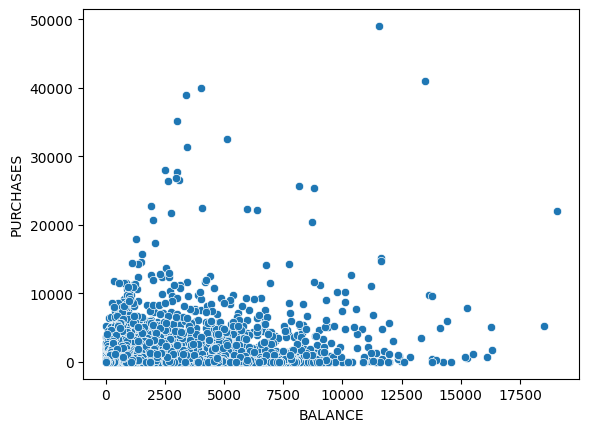

In [ ]:
# let's visualize the data as is, before clustering
sns.scatterplot(x="BALANCE", y="PURCHASES", data=df, palette="tab10")

### KMeans requires list of variables/data for clustering

In [ ]:
# save all data to X-variable (used later in the algorithm as "training data")
X = df.values
X

array([[  40.900749,   95.4     ],
       [3202.467416,    0.      ],
       [2495.148862,  773.17    ],
       ...,
       [  23.398673,  144.4     ],
       [  13.457564,    0.      ],
       [ 372.708075, 1093.25    ]], shape=(8950, 2))

### In order to know the optimal cluster amount for k => elbow method!

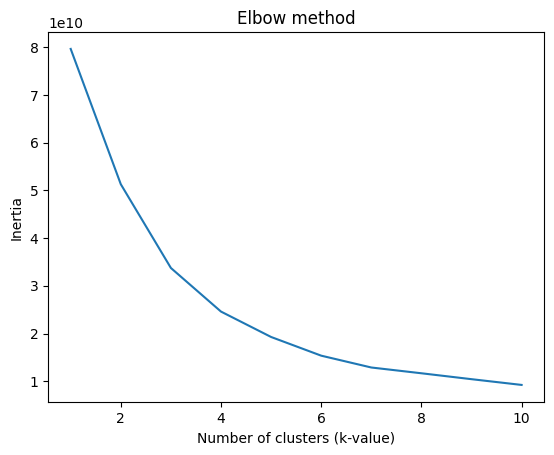

In [116]:
# let's use the elbow method
inertias = []

# using a for loop to iterate through clusters from 1 to 10
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)

# visualize the elbow
plt.plot(range(1, 11), inertias)
plt.title("Elbow method")
plt.xlabel('Number of clusters (k-value)')
plt.ylabel('Inertia')
plt.show()

### Let's use 4 clusters (even though 3-5 are probably all useful here)

In [117]:
# finally, train the actual KMEAN-algorithm
kmeans = KMeans(n_clusters=4, init="k-means++", random_state=42)
predictions = kmeans.fit_predict(X)

In [118]:
predictions

array([1, 1, 1, ..., 1, 1, 1], shape=(8950,), dtype=int32)

In [119]:
# let's attach the clusters back to original data
df['CLUSTER'] = predictions

In [ ]:
# let's see some random clustering
df.sample(10)

,BALANCE,PURCHASES,CLUSTER
7157,2224.891476,211.05,1
5216,1753.279980,245.85,1
2692,2241.092286,1260.00,1
7556,34.703482,247.02,1
3681,2403.175046,0.00,1
5214,1283.812260,166.90,1
7186,0.000000,269.28,1
3160,226.353960,2455.75,1
6447,4.924829,65.97,1
6909,2702.523396,229.25,1


<Axes: xlabel='BALANCE', ylabel='PURCHASES'>

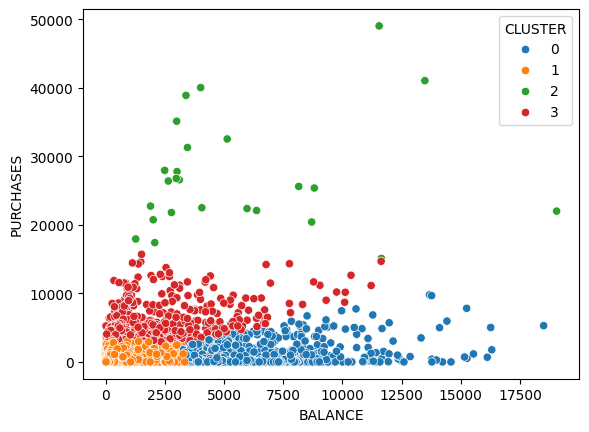

In [ ]:
# let's visualize the clusters
sns.scatterplot(x="BALANCE", y="PURCHASES", hue="CLUSTER", data=df, palette="tab10")

In [ ]:
# it's also possible to get basic statistics based on the clusters
# also a min/max -version would be helpful => what balance ranges 
# the different clusters have etc.
df.groupby(['CLUSTER']).mean()[['BALANCE', 'PURCHASES']]

,BALANCE,PURCHASES
CLUSTER,,
0,5773.636543,861.812233
1,831.528156,582.186501
2,5640.478051,27187.570000
3,2098.200622,5561.780842


### Based on these averages, it seems we have four groups of customers:

In [ ]:
# Cluster 0 = High BALANCE, low/medium purchases
# Cluster 1 = Low balance, low purchases
# Cluster 2 = High balance, EXTREMELY high purchases 
# Cluster 3 = Medium balance, High purchases

# we could use this information in order to study further what 
# kind of products were bought by each customer group, what are 
# their typical patterns in the shop etc.

In [ ]:
# it seems the clusters are not ver balanced
# most customers in cluster 1
df['CLUSTER'].value_counts()

CLUSTER
1    7207
0    1160
3     558
2      25
Name: count, dtype: int64